**UPLOADING FLIES**

In [87]:
from google.colab import files
uploaded = files.upload()

**IMPORT LIBRARIES**

In [112]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**LOAD  DATASETS**

In [113]:
transactions = pd.read_excel("QVI_transaction_data.xlsx")
customers = pd.read_csv("QVI_purchase_behaviour.csv")


transactions.head()
customers.head()

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream


**CHECK STRUCTURES**

In [115]:
transactions.info()
transactions.describe()

customers.info()
customers.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   DATE            264836 non-null  int64  
 1   STORE_NBR       264836 non-null  int64  
 2   LYLTY_CARD_NBR  264836 non-null  int64  
 3   TXN_ID          264836 non-null  int64  
 4   PROD_NBR        264836 non-null  int64  
 5   PROD_NAME       264836 non-null  object 
 6   PROD_QTY        264836 non-null  int64  
 7   TOT_SALES       264836 non-null  float64
dtypes: float64(1), int64(6), object(1)
memory usage: 16.2+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72637 entries, 0 to 72636
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   LYLTY_CARD_NBR    72637 non-null  int64 
 1   LIFESTAGE         72637 non-null  object
 2   PREMIUM_CUSTOMER  72637 non-null  object
dtypes: int64(1), object(2)
m

,LYLTY_CARD_NBR
count,7.263700e+04
mean,1.361859e+05
std,8.989293e+04
min,1.000000e+03
25%,6.620200e+04
50%,1.340400e+05
75%,2.033750e+05
max,2.373711e+06


**Check Missing Values**

In [116]:
transactions.isnull().sum()
customers.isnull().sum()

,0
LYLTY_CARD_NBR,0
LIFESTAGE,0
PREMIUM_CUSTOMER,0


**DATA CONVERSION**

In [106]:
transactions["DATE"] = pd.to_datetime(transactions["DATE"], origin="1899-12-30", unit='D')

**REMOVE SALSA PRODUCTS**

In [117]:
transactions = transactions[~transactions["PROD_NAME"].str.lower().str.contains("salsa")]

**REMOVE OUTLIER CUSTOMERS**

In [118]:
transactions = transactions[transactions["LYLTY_CARD_NBR"] != 226000]

**SUMMARY**

In [119]:
transactionData.describe()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES,PACK_SIZE
count,246740,246740.000000,2.467400e+05,2.467400e+05,246740.000000,246740.000000,246740.000000,246740.000000
mean,2018-12-30 01:18:58.448569344,135.050361,1.355303e+05,1.351304e+05,56.352213,1.906456,7.316113,175.583521
min,2018-07-01 00:00:00,1.000000,1.000000e+03,1.000000e+00,1.000000,1.000000,1.700000,70.000000
25%,2018-09-30 00:00:00,70.000000,7.001500e+04,6.756875e+04,26.000000,2.000000,5.800000,150.000000
50%,2018-12-30 00:00:00,130.000000,1.303670e+05,1.351815e+05,53.000000,2.000000,7.400000,170.000000
75%,2019-03-31 00:00:00,203.000000,2.030832e+05,2.026522e+05,87.000000,2.000000,8.800000,175.000000
max,2019-06-30 00:00:00,272.000000,2.373711e+06,2.415841e+06,114.000000,5.000000,29.500000,380.000000
std,NaN,76.786971,8.071520e+04,7.814760e+04,33.695235,0.342499,2.474897,59.432118


**TRANSACTIONS PER DAY PLOT**

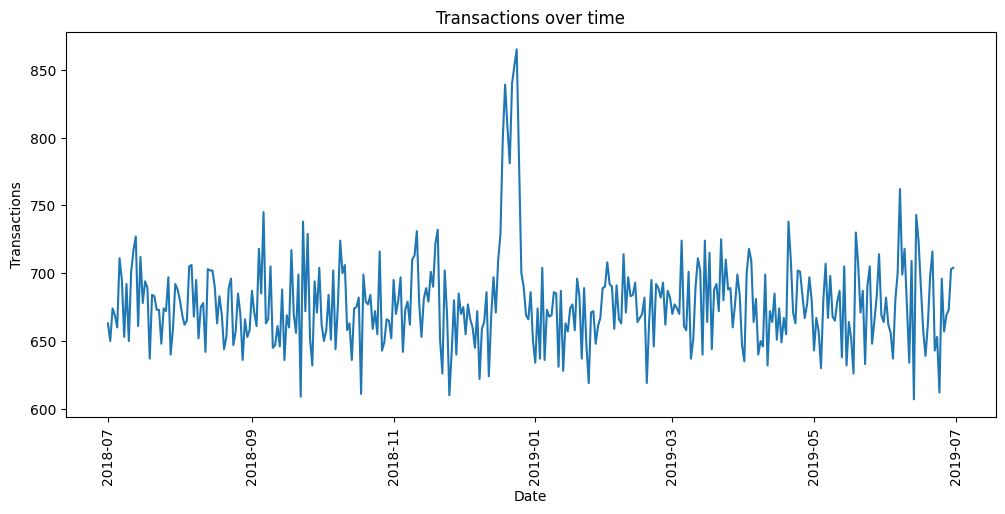

In [126]:
transactions_by_day = transactionData.groupby('DATE').size().reset_index(name='N')

plt.figure(figsize=(12,5))
plt.plot(transactions_by_day['DATE'], transactions_by_day['N'])
plt.xticks(rotation=90)
plt.title("Transactions over time")
plt.xlabel("Date")
plt.ylabel("Transactions")
plt.show()

**CREATE PACK_SIZE**

In [121]:
transactions["PACK_SIZE"] = transactions["PROD_NAME"].str.extract(r'(\d+)').astype(float)

**CRREATE BRAND EXTRACTION**

In [123]:
transactions["BRAND"] = transactions["PROD_NAME"].str.split().str[0].str.upper()

**CLEAN BRAND NAMES**

In [127]:
transactions["BRAND"] = transactions["BRAND"].replace({
    "RED": "RRD",
    "SNBTS": "SUNBITES",
    "INFZNS": "INFUZIONS",
    "WW": "WOOLWORTHS",
    "SMITH": "SMITHS",
    "NCC": "NATURAL",
    "DORITO": "DORITOS",
    "GRAIN": "GRNWVES"
})


**MERGE DATASETS**

In [128]:
data = transactions.merge(customers, on="LYLTY_CARD_NBR", how="left")


**TOTAL SALES BY SEGMENT**

In [129]:
sales = data.groupby(["LIFESTAGE", "PREMIUM_CUSTOMER"])["TOT_SALES"].sum().reset_index()
print(sales)

                 LIFESTAGE PREMIUM_CUSTOMER  TOT_SALES
0   MIDAGE SINGLES/COUPLES           Budget   33345.70
1   MIDAGE SINGLES/COUPLES       Mainstream   84734.25
2   MIDAGE SINGLES/COUPLES          Premium   54443.85
3             NEW FAMILIES           Budget   20607.45
4             NEW FAMILIES       Mainstream   15979.70
5             NEW FAMILIES          Premium   10760.80
6           OLDER FAMILIES           Budget  156863.75
7           OLDER FAMILIES       Mainstream   96413.55
8           OLDER FAMILIES          Premium   75242.60
9    OLDER SINGLES/COUPLES           Budget  127833.60
10   OLDER SINGLES/COUPLES       Mainstream  124648.50
11   OLDER SINGLES/COUPLES          Premium  123537.55
12                RETIREES           Budget  105916.30
13                RETIREES       Mainstream  145168.95
14                RETIREES          Premium   91296.65
15          YOUNG FAMILIES           Budget  129717.95
16          YOUNG FAMILIES       Mainstream   86338.25
17        

**NUMBERS OF CUSTOMERS**

In [131]:
customers = data.groupby(['LIFESTAGE','PREMIUM_CUSTOMER'])['LYLTY_CARD_NBR'].nunique().reset_index()
customers.rename(columns={'LYLTY_CARD_NBR':'CUSTOMERS'}, inplace=True)

**AVG PRICE PER UNIT**

In [132]:
avg_price = data.groupby(["LIFESTAGE", "PREMIUM_CUSTOMER"]) \
    .apply(lambda x: x["TOT_SALES"].sum() / x["PROD_QTY"].sum()) \
    .reset_index(name="AVG_PRICE")


/tmp/ipykernel_207/4260910574.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x["TOT_SALES"].sum() / x["PROD_QTY"].sum()) \


**T -TEST**

In [133]:
from scipy.stats import ttest_ind

subset1 = data[
    (data["LIFESTAGE"].isin(["YOUNG SINGLES/COUPLES", "MIDAGE SINGLES/COUPLES"])) &
    (data["PREMIUM_CUSTOMER"] == "Mainstream")
]["TOT_SALES"] / data["PROD_QTY"]

subset2 = data[
    (data["LIFESTAGE"].isin(["YOUNG SINGLES/COUPLES", "MIDAGE SINGLES/COUPLES"])) &
    (data["PREMIUM_CUSTOMER"] != "Mainstream")
]["TOT_SALES"] / data["PROD_QTY"]

ttest_ind(subset1, subset2, alternative='greater')

TtestResult(statistic=np.float64(nan), pvalue=np.float64(nan), df=np.float64(nan))

**PLOT(Python version of ggplot)**

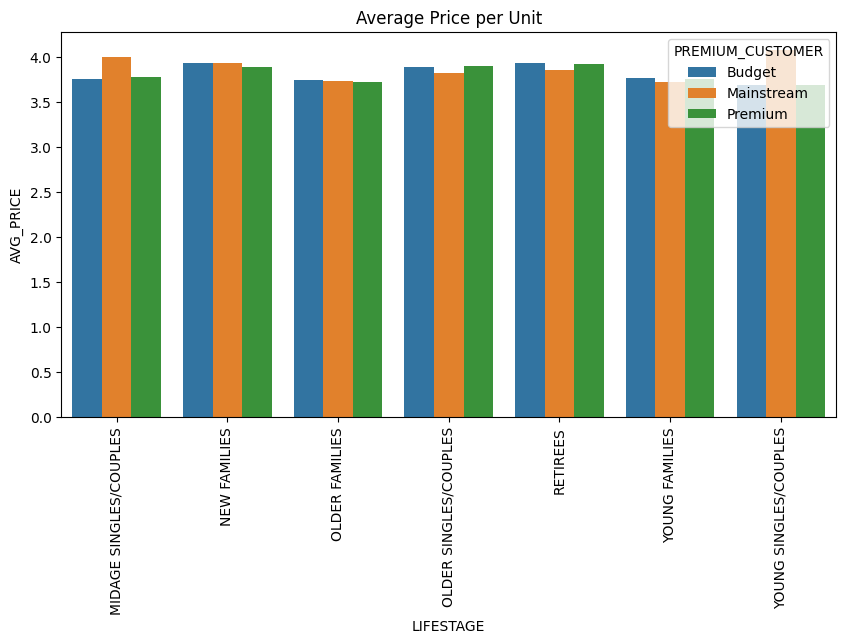

In [134]:
plt.figure(figsize=(10,5))
sns.barplot(data=avg_price, x='LIFESTAGE', y='AVG_PRICE', hue='PREMIUM_CUSTOMER')
plt.xticks(rotation=90)
plt.title("Average Price per Unit")
plt.show()